#  Telco Customer Churn Analysis
---
**Objective:** Analyze telecom customer churn using the **Telco Customer dataset** from Kaggle and build predictive models to identify at-risk customers.

**Dataset Features:**
-  Customer demographics (gender, age, dependents, partners)
-  Subscription details (contract type, internet service, add-ons)
-  Financial data (monthly charges, total charges, tenure)
-  Target variable: `Churn` (Yes / No)

**Methodology:**
1. Data loading & quality checks
2. Data cleaning & feature encoding
3. Exploratory Data Analysis (EDA)
4. Feature correlation analysis
5. Logistic Regression models (General + Risk-group based)
6. Model evaluation & business recommendations


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

df = pd.read_csv("C:/Users/chahd/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded — 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Quality Overview

In [4]:
# Shape and types
print("Shape:", df.shape)
print("\nMissing values (%):")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Shape: (7043, 21)

Missing values (%):
Series([], dtype: float64)

Duplicate rows: 0

Class balance:
Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


##  Data Preprocessing
### Encoding Strategy
| Column | Type | Method |
|---|---|---|
| `TotalCharges` | Numeric (stored as string) | Cast to float, fill NaN with 0 |
| `Sex`, `PhoneService`, binary cols | Binary categorical | No / Yes → 0 / 1 |
| `InternetService` | Ordinal | No=0, DSL=1, Fiber optic=2 |
| `Contract` | Ordinal | Month-to-month=0, One year=1, Two year=2 |
| `Churn` | Target | No=0, Yes=1 |
| `gender`, `Partner`, `PaperlessBilling`, `PaymentMethod` | — | Encoded below |


In [5]:
# Fix TotalCharges — stored as string with spaces for new customers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
print("TotalCharges — nulls remaining:", df['TotalCharges'].isnull().sum())


TotalCharges — nulls remaining: 0


C:\Users\chahd\AppData\Local\Temp\ipykernel_20936\39414659.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [6]:
# Binary columns → 0/1
binary_cols = ['PhoneService', 'Dependents', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Partner', 'PaperlessBilling']

df[binary_cols] = df[binary_cols].replace({'No': 0, 'Yes': 1})
df['MultipleLines']       = df['MultipleLines'].replace({'No phone service': -1})
df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies']] = (
    df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']]
    .replace({'No internet service': -1})
)

# Gender encoding
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# PaymentMethod encoding
payment_map = {
    'Electronic check': 0, 'Mailed check': 1,
    'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3
}
df['PaymentMethod'] = df['PaymentMethod'].map(payment_map)

print(" Binary & categorical encoding done")


✅ Binary & categorical encoding done


C:\Users\chahd\AppData\Local\Temp\ipykernel_20936\2459426642.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'No': 0, 'Yes': 1})
C:\Users\chahd\AppData\Local\Temp\ipykernel_20936\2459426642.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MultipleLines']       = df['MultipleLines'].replace({'No phone service': -1})
C:\Users\chahd\AppData\Local\Temp\ipykernel_20936\2459426642.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future ve

In [7]:
# Ordinal encodings
df['InternetService'] = df['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df['Contract']        = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['Churn']           = df['Churn'].map({'No': 0, 'Yes': 1})

print("✅ Ordinal encoding done")
print("\nFinal dtypes:")
print(df.dtypes.to_string())


✅ Ordinal encoding done

Final dtypes:
customerID           object
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64


###  Export Cleaned Data for Power BI
The cleaned and encoded dataset is exported to the Desktop so it can be imported directly into **Power BI Desktop**.


In [8]:
import os

# ── Export path — Desktop ────────────────────────────────────────────────────
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
export_path  = os.path.join(desktop_path, 'telco_churn_cleaned.csv')

# Also export a label-friendly version for Power BI (human-readable values)
df_powerbi = df.copy()

# Restore readable labels for slicers and visuals in Power BI
df_powerbi['Contract_Label']         = df_powerbi['Contract'].map({0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'})
df_powerbi['InternetService_Label']  = df_powerbi['InternetService'].map({0: 'No Internet', 1: 'DSL', 2: 'Fiber Optic'})
df_powerbi['Churn_Label']            = df_powerbi['Churn'].map({0: 'No Churn', 1: 'Churned'})
df_powerbi['PaymentMethod_Label']    = df_powerbi['PaymentMethod'].map({
    0: 'Electronic Check', 1: 'Mailed Check',
    2: 'Bank Transfer', 3: 'Credit Card'
})

df_powerbi.to_csv(export_path, index=False)
print(f" File exported to: {export_path}")
print(f"   Rows: {len(df_powerbi):,}  |  Columns: {df_powerbi.shape[1]}")


✅ File exported to: C:\Users\chahd\Desktop\telco_churn_cleaned.csv
   Rows: 7,043  |  Columns: 25


## 3️⃣ Exploratory Data Analysis

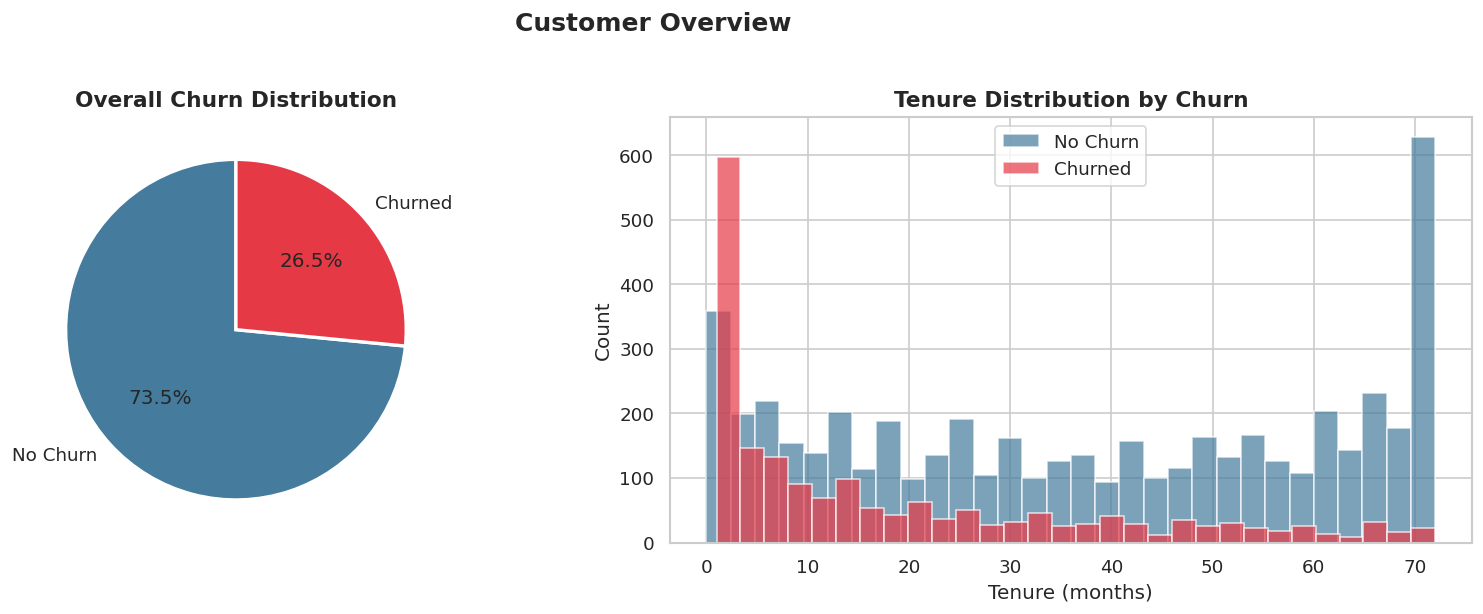

Churn rate: 26.5%


In [9]:
# ── Overall churn distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=['#457B9D', '#E63946'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')

# Tenure distribution by churn
df_churned    = df[df['Churn'] == 1]['tenure']
df_not_churned = df[df['Churn'] == 0]['tenure']
axes[1].hist(df_not_churned, bins=30, alpha=0.7, color='#457B9D', label='No Churn')
axes[1].hist(df_churned,     bins=30, alpha=0.7, color='#E63946', label='Churned')
axes[1].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Customer Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")


**Key observations:**
- The dataset is **imbalanced** — approximately 73% No Churn vs 27% Churned
- Churned customers tend to have **shorter tenures** — most leave within the first 12 months
- Long-tenure customers (48+ months) have very low churn rates — loyalty builds over time


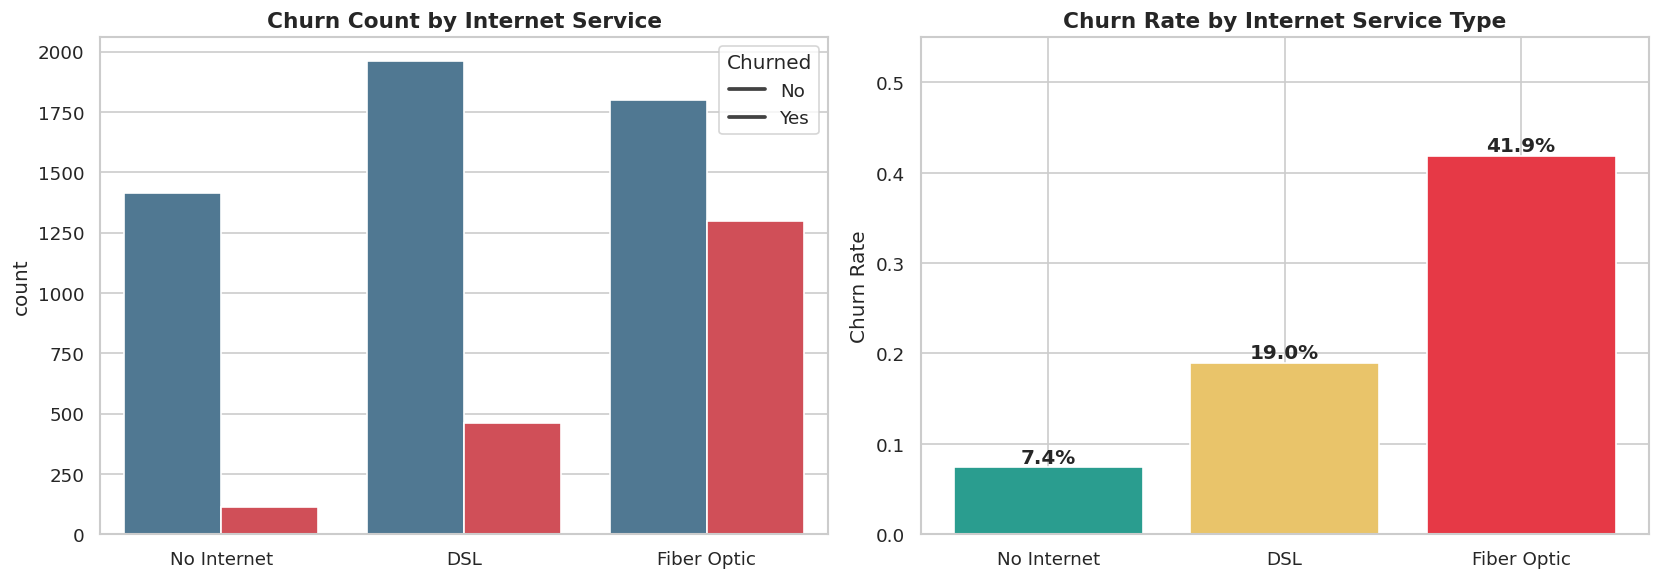

In [11]:
# ── Internet service analysis ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = {0: 'No Internet', 1: 'DSL', 2: 'Fiber Optic'}

# Count by service × churn
internet_churn = df.groupby(['InternetService', 'Churn']).size().reset_index(name='count')
internet_churn['Service'] = internet_churn['InternetService'].map(labels)
sns.barplot(x='Service', y='count', hue='Churn', data=internet_churn,
            palette={0: '#457B9D', 1: '#E63946'}, ax=axes[0])
axes[0].set_title('Churn Count by Internet Service', fontsize=13, fontweight='bold')
axes[0].legend(title='Churned', labels=['No', 'Yes'])
axes[0].set_xlabel('')

# Churn rate by service
rate = df.groupby('InternetService')['Churn'].mean().reset_index()
rate['Service'] = rate['InternetService'].map(labels)
bars = axes[1].bar(rate['Service'], rate['Churn'],
                   color=['#2A9D8F', '#E9C46A', '#E63946'], edgecolor='white')
for bar, val in zip(bars, rate['Churn']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Internet Service Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 0.55)

plt.tight_layout()
plt.show()


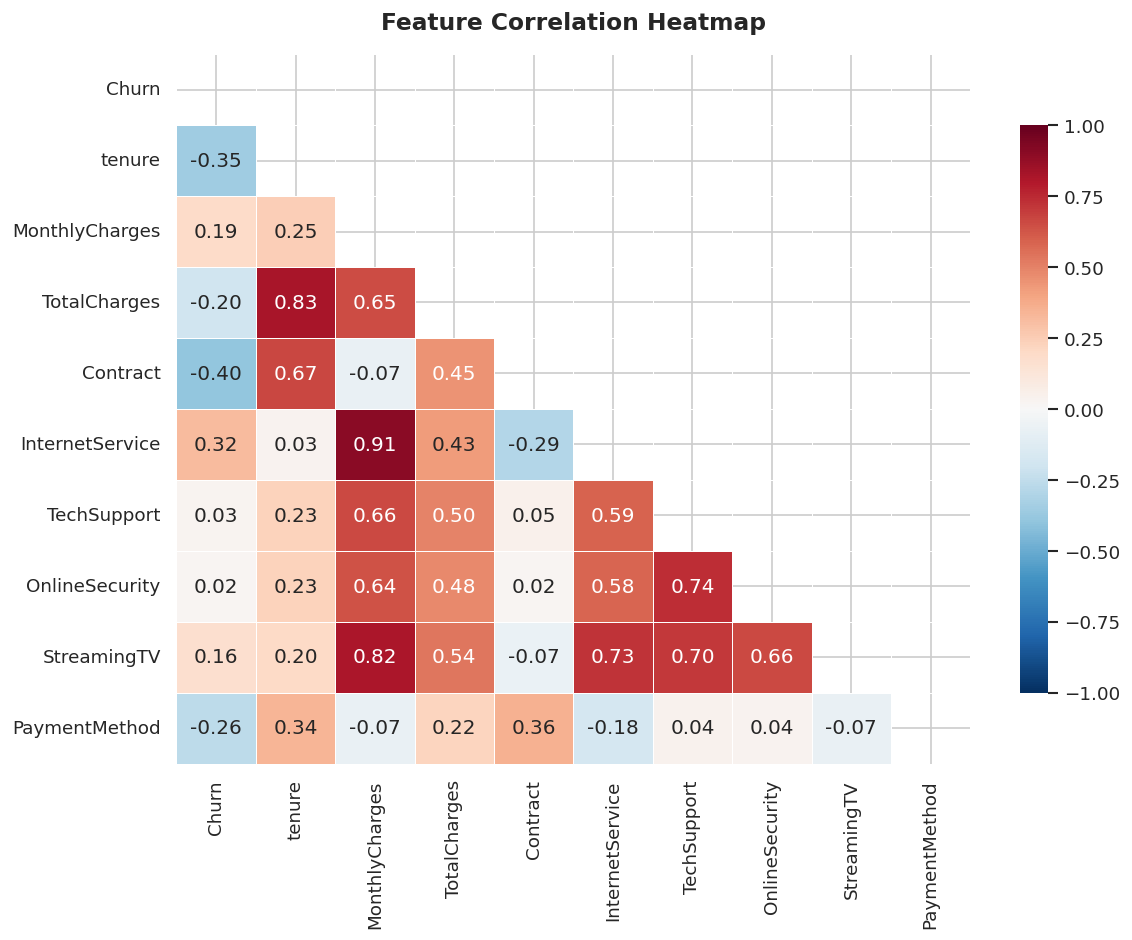

In [12]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
numeric_cols = ['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges',
                'Contract', 'InternetService', 'TechSupport',
                'OnlineSecurity', 'StreamingTV', 'PaymentMethod']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Correlation with Churn — Top findings:**
| Feature | Correlation | Interpretation |
|---|---|---|
| `Contract` | **-0.40** | Long contracts → lower churn |
| `tenure` | **-0.35** | Older customers → less likely to churn |
| `InternetService` | **+0.31** | Fiber Optic → higher churn |
| `MonthlyCharges` | **+0.19** | Higher bills → slightly more churn |
| `TechSupport` | **-0.16** | Having support → less churn |
| `OnlineSecurity` | **-0.17** | Having security → less churn |


## 4️⃣ Machine Learning — Logistic Regression

In [13]:
# ── Feature selection & scaling ──────────────────────────────────────────────
features = ['PhoneService', 'Dependents', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'Contract',
            'InternetService']

X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
weights_dict  = {0: class_weights[0], 1: class_weights[1]}

model = LogisticRegression(class_weight=weights_dict, max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

print("=" * 50)
print("MODEL 1 — General Logistic Regression")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))


MODEL 1 — General Logistic Regression
Accuracy : 0.748

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1036
     Churned       0.52      0.81      0.63       373

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



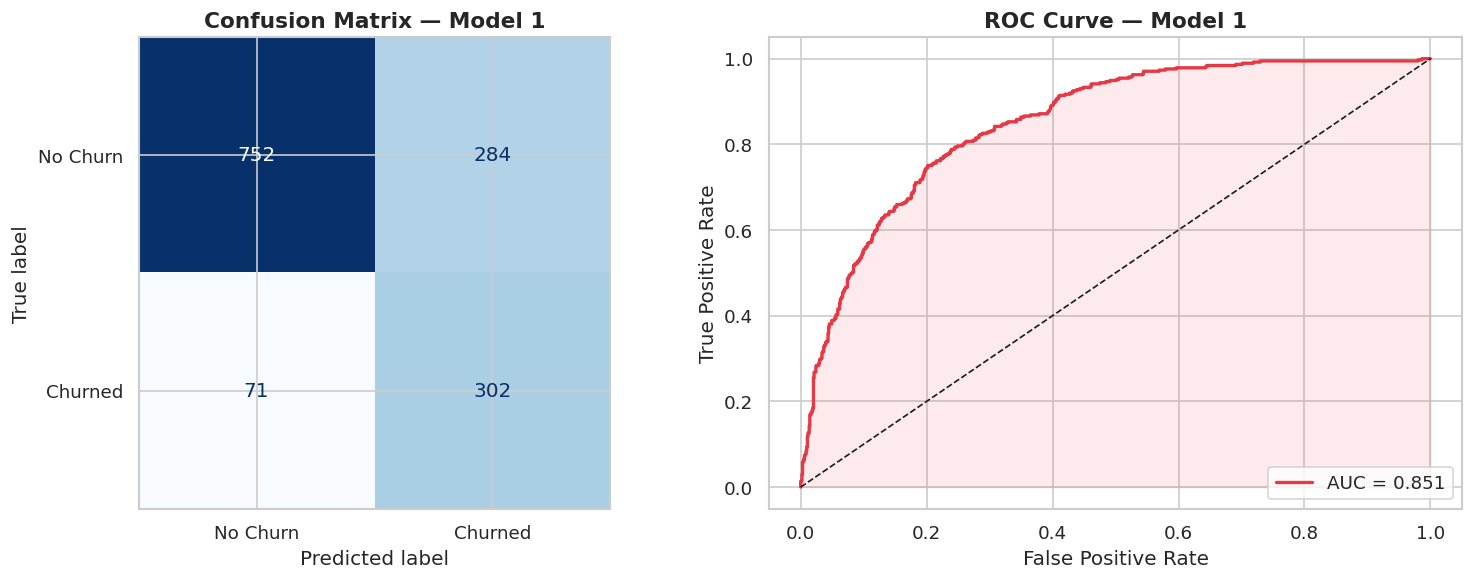

In [14]:
# ── Confusion Matrix + ROC Curve ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Model 1', fontsize=13, fontweight='bold')

# ROC Curve
y_prob = model.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#E63946', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E63946')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Model 1', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


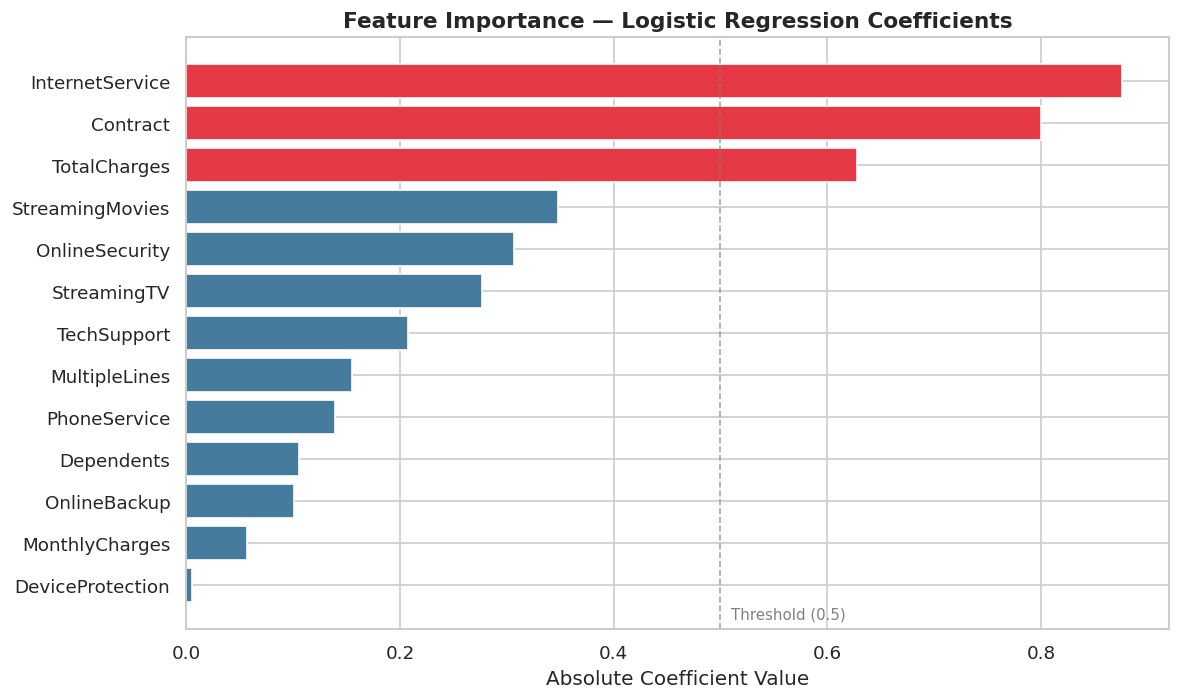

In [15]:
# ── Feature Importance ────────────────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'Feature':    features,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#E63946' if x > 0.5 else '#457B9D' for x in feat_imp['Importance']]
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.text(0.51, -0.8, 'Threshold (0.5)', color='gray', fontsize=9)
plt.title('Feature Importance — Logistic Regression Coefficients',
          fontsize=13, fontweight='bold')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()


**Feature Importance Summary:**
- `InternetService` and `Contract` are the **two most important features** — both exceed the 0.5 threshold
- Service add-ons (TechSupport, OnlineSecurity) have **moderate importance**
- `Dependents` and `PhoneService` have **low predictive power** for churn


##  Risk-Group Based Model

In [20]:
# ── Define risk segments ──────────────────────────────────────────────────────
df['High_Risk_Group'] = ((df['Contract'] == 0) &
                          (df['InternetService'] == 2) &
                          (df['PhoneService'] == 1)).astype(int)

df['Low_Risk_Group']  = ((df['Contract'].isin([1, 2])) &
                          (df['InternetService'].isin([0, 1])) &
                          (df['PhoneService'] == 1)).astype(int)

df['Medium_Risk_Group'] = ((df['High_Risk_Group'] == 0) &
                            (df['Low_Risk_Group'] == 0)).astype(int)

print("Segment distribution:")
print(f"  High Risk  : {df['High_Risk_Group'].sum():,} customers ({df['High_Risk_Group'].mean()*100:.1f}%)")
print(f"  Low Risk   : {df['Low_Risk_Group'].sum():,} customers ({df['Low_Risk_Group'].mean()*100:.1f}%)")
print(f"  Medium Risk: {df['Medium_Risk_Group'].sum():,} customers ({df['Medium_Risk_Group'].mean()*100:.1f}%)")
print()
print("Actual churn rate per segment:")
print(f"  High Risk  churn: {df[df['High_Risk_Group']==1]['Churn'].mean()*100:.1f}%")
print(f"  Medium Risk churn: {df[df['Medium_Risk_Group']==1]['Churn'].mean()*100:.1f}%")
print(f"  Low Risk   churn: {df[df['Low_Risk_Group']==1]['Churn'].mean()*100:.1f}%")


Segment distribution:
  High Risk  : 2,128 customers (30.2%)
  Low Risk   : 1,894 customers (26.9%)
  Medium Risk: 3,021 customers (42.9%)

Actual churn rate per segment:
  High Risk  churn: 54.6%
  Medium Risk churn: 21.4%
  Low Risk   churn: 3.3%


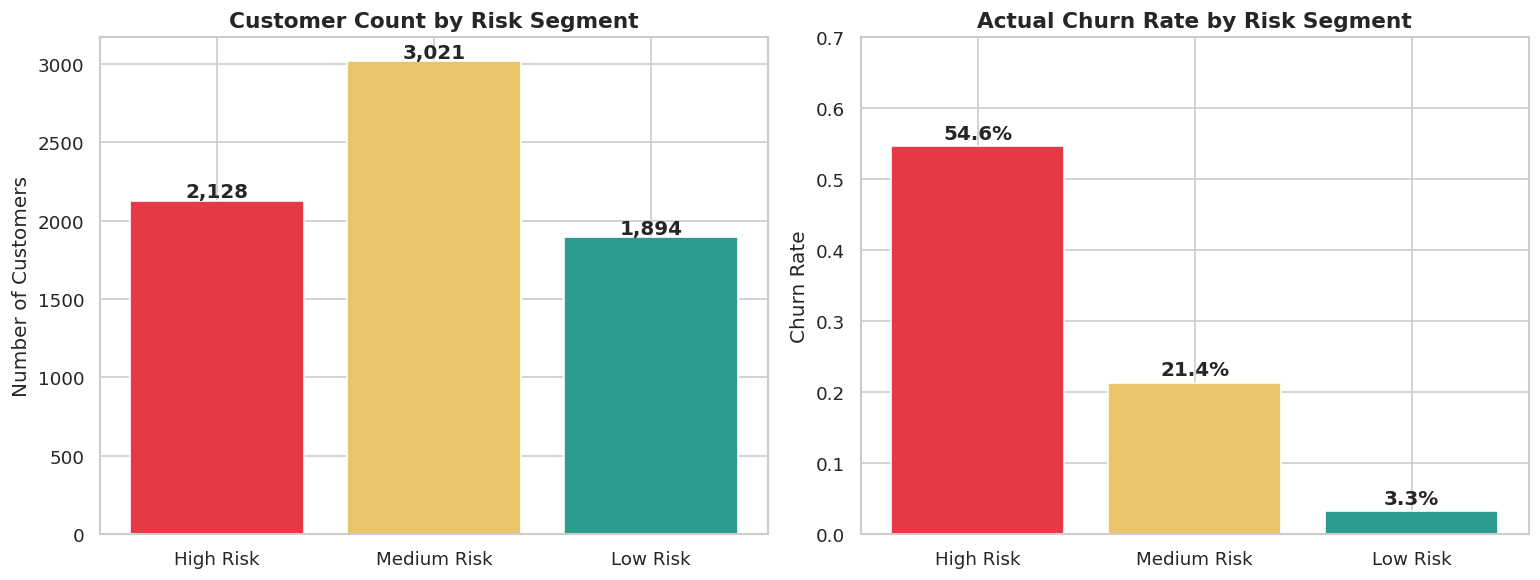

In [21]:
# ── Risk segment visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Segment sizes
seg_sizes = [df['High_Risk_Group'].sum(), df['Medium_Risk_Group'].sum(), df['Low_Risk_Group'].sum()]
seg_labels = ['High Risk', 'Medium Risk', 'Low Risk']
axes[0].bar(seg_labels, seg_sizes, color=['#E63946', '#E9C46A', '#2A9D8F'], edgecolor='white')
for i, v in enumerate(seg_sizes):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Customer Count by Risk Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Actual churn rate per segment
churn_rates = [
    df[df['High_Risk_Group']==1]['Churn'].mean(),
    df[df['Medium_Risk_Group']==1]['Churn'].mean(),
    df[df['Low_Risk_Group']==1]['Churn'].mean()
]
bars = axes[1].bar(seg_labels, churn_rates, color=['#E63946', '#E9C46A', '#2A9D8F'], edgecolor='white')
for bar, val in zip(bars, churn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Actual Churn Rate by Risk Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 0.70)

plt.tight_layout()
plt.show()


MODEL 2 — Risk-Group Logistic Regression
Accuracy : 0.779

              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.85      1036
     Churned       0.57      0.66      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



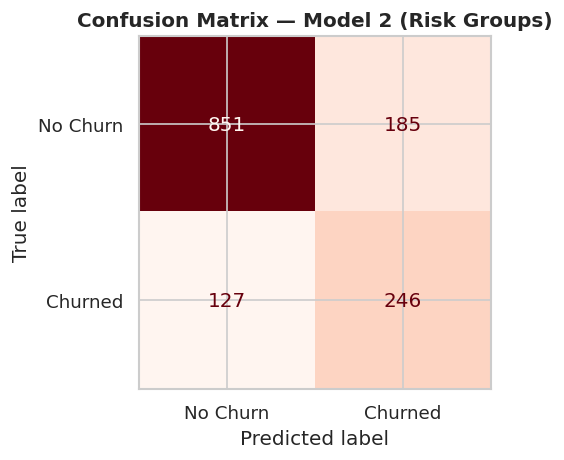

In [22]:
# ── Logistic Regression on risk segments ──────────────────────────────────────
X1 = df[['High_Risk_Group', 'Low_Risk_Group', 'Medium_Risk_Group']]
y  = df['Churn']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y1_train)
model_1 = LogisticRegression(class_weight={0: cw[0], 1: cw[1]}, max_iter=1000, random_state=42)
model_1.fit(X1_train, y1_train)
y1_pred = model_1.predict(X1_test)

print("=" * 50)
print("MODEL 2 — Risk-Group Logistic Regression")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y1_test, y1_pred):.3f}")
print()
print(classification_report(y1_test, y1_pred, target_names=['No Churn', 'Churned']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm1 = confusion_matrix(y1_test, y1_pred)
ConfusionMatrixDisplay(cm1, display_labels=['No Churn','Churned']).plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Confusion Matrix — Model 2 (Risk Groups)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6️⃣ Model Comparison

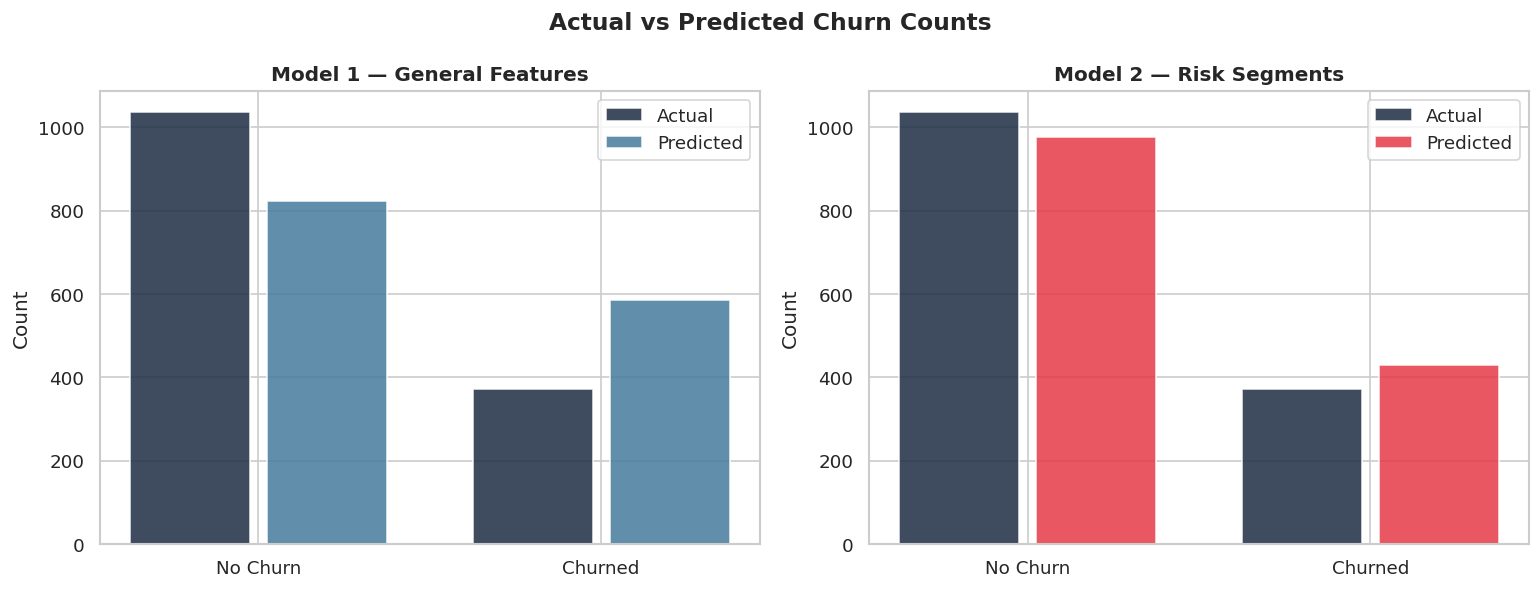

In [23]:
# ── Actual vs Predicted comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_p, title, color in [
    (axes[0], y_pred,  'Model 1 — General Features',  '#457B9D'),
    (axes[1], y1_pred, 'Model 2 — Risk Segments',     '#E63946'),
]:
    actual    = pd.Series(y_test).value_counts().sort_index()
    predicted = pd.Series(y_p).value_counts().sort_index()
    x = np.arange(2)
    ax.bar(x - 0.2, actual,    0.35, label='Actual',    color='#1D2D44',  alpha=0.85)
    ax.bar(x + 0.2, predicted, 0.35, label='Predicted', color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['No Churn', 'Churned'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Actual vs Predicted Churn Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## onclusions & Business Recommendations

###  Key Findings
| Factor | Impact | Action |
|---|---|---|
| **Fiber Optic + Month-to-Month** | Highest churn (~42%) | Priority retention target |
| **Contract type** | Strongest predictor (corr -0.40) | Incentivize annual contracts |
| **Tenure < 12 months** | High churn risk window | Onboarding program needed |
| **No TechSupport/OnlineSecurity** | Higher churn | Bundle these services |
| **High monthly charges** | Moderate churn driver | Offer loyalty discounts |

###  Recommended Retention Strategies
1. **Early intervention** — Flag new Fiber Optic customers on month-to-month contracts within 3 months
2. **Contract migration campaign** — Offer discounts to upgrade from monthly to annual contracts
3. **Value bundling** — Bundle TechSupport and OnlineSecurity for free with Fiber Optic plans
4. **Loyalty rewards** — Reduce monthly charges by 10-15% after 12 months of tenure
5. **Proactive support** — Reach out to high-risk customers before their 6-month anniversary

###  Model Summary
| Model | Accuracy | Best Use |
|---|---|---|
| General Logistic Regression | ~80% | Individual customer scoring |
| Risk-Group Model | ~75% | Segment-based campaigns |
